# M.A.C.E Pipeline — Multi-tier Adaptive Compositional Embedding
## CTR Prediction với DeepFM · DCN · DLRM trên Criteo Cleaned Data

---

### Kiến trúc M.A.C.E
```
INPUT (ID Features)
       │
       ▼
┌─────────────────────────────────────────┐
│   Stage 1: Traffic Cop                  │
│   Count-Min Sketch → Frequency Routing  │
└────────┬──────────────┬─────────────────┘
         │              │              │
         ▼              ▼              ▼
  ┌──────────┐  ┌──────────────┐  ┌──────────┐
  │ VIP Lane │  │ Standard Lane│  │Dust Lane │
  │  1:1 LUT │  │  QR-Trick    │  │   DHE    │
  │  d = 64  │  │  d = 32      │  │  d = 16  │
  └────┬─────┘  └──────┬───────┘  └────┬─────┘
       │               │               │
       └───────────────┴───────────────┘
                       │
                       ▼
           ┌───────────────────────┐
           │  Stage 3: Unified     │
           │  Projection Layer     │
           │  → D = 64 cho tất cả  │
           └───────────┬───────────┘
                       │
           ┌───────────┼───────────┐
           ▼           ▼           ▼
        DeepFM        DCN        DLRM
```


## 0. Cài đặt thư viện

In [3]:
%%capture
!pip install pyarrow pandas numpy scikit-learn torch torchmetrics tqdm matplotlib seaborn

## 1. Imports & Config

In [4]:
import os
import gc
import time
import math
import json
import hashlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import OneCycleLR

from sklearn.metrics import roc_auc_score, log_loss, average_precision_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────────────────────────────────────
# CONFIG — chỉnh ở đây
# ──────────────────────────────────────────────────────────────────────────────
CFG = {
    # Data
    'data_dir'      : '/kaggle/input/datasets/huy291/criteo-cleaned-data/data',
    'n_files_train' : 45,          # file 0-44 cho train
    'n_files_val'   : 5,           # file 45-49 cho val
    'sample_frac'   : 0.15,         # 1.0 = dùng toàn bộ; giảm xuống 0.2 nếu muốn test nhanh

    # M.A.C.E Tier thresholds
    'tier_vip_pct'  : 0.05,        # top 5% → VIP 1:1
    'tier_mid_pct'  : 0.30,        # top 30% → QR-Trick
                                   # còn lại → DHE

    # Embedding dims per tier
    'dim_vip'       : 64,
    'dim_mid'       : 32,
    'dim_tail'      : 16,
    'dim_unified'   : 64,          # Projection đầu ra

    # QR trick
    'qr_bucket_size': 2000,

    # DHE
    'dhe_n_hashes'  : 8,           # số hàm băm
    'dhe_hidden'    : 128,         # hidden size của MLP
    'dhe_layers'    : 2,

    # Count-Min Sketch
    'cms_depth'     : 5,
    'cms_width'     : 2**20,       # ~1M buckets

    # Numerical
    'n_dense'       : 13,          # I1-I13

    # Training
    'batch_size'    : 4096,
    'epochs'        : 5,
    'lr'            : 1e-3,
    'weight_decay'  : 1e-5,
    'pos_weight'    : 2.9,         
    'device'        : 'cuda' if torch.cuda.is_available() else 'cpu',
    'seed'          : 42,

    # Numerical
    'dense_hidden'  : [256, 128],
    'dropout'       : 0.2,

    # Model-specific
    'dcn_n_cross'   : 3,
    'dlrm_bot_mlp'  : [64, 128, 64],
    'dlrm_top_mlp'  : [512, 256, 128],
}

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
device = torch.device(CFG['device'])
print(f" Device: {device}")
print(f" Config loaded — {CFG['epochs']} epochs, batch={CFG['batch_size']}")

 Device: cuda
 Config loaded — 5 epochs, batch=4096


## 2. Load & Preprocess Data

In [5]:
DENSE_COLS = [f'I{i}' for i in range(1, 14)]
SPARSE_COLS = [f'C{i}' for i in range(1, 27)]
LABEL_COL = 'label'
ALL_COLS = [LABEL_COL] + DENSE_COLS + SPARSE_COLS

data_dir = Path(CFG['data_dir'])
files = sorted(data_dir.glob('train-*.parquet'))
print(f" Tìm thấy {len(files)} file parquet")

train_files = files[:CFG['n_files_train']]
val_files   = files[CFG['n_files_train']:CFG['n_files_train'] + CFG['n_files_val']]

def load_files(file_list, sample_frac=1.0, desc='Loading'):
    dfs = []
    for f in tqdm(file_list, desc=desc):
        df = pd.read_parquet(f, columns=ALL_COLS)
        if sample_frac < 1.0:
            df = df.sample(frac=sample_frac, random_state=CFG['seed'])
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

print(" Loading train data...")
df_train = load_files(train_files, CFG['sample_frac'], 'Train')
print(f"   Train: {len(df_train):,} rows")

print(" Loading val data...")
df_val = load_files(val_files, CFG['sample_frac'], 'Val')
print(f"   Val:   {len(df_val):,} rows")

print(f"\n Label distribution (train):")
vc = df_train[LABEL_COL].value_counts()
print(f"   Not clicked (0): {vc[0]:,} ({vc[0]/len(df_train)*100:.1f}%)")
print(f"   Clicked     (1): {vc[1]:,} ({vc[1]/len(df_train)*100:.1f}%)")

 Tìm thấy 50 file parquet
 Loading train data...


Train:   0%|          | 0/45 [00:00<?, ?it/s]

   Train: 6,210,173 rows
 Loading val data...


Val:   0%|          | 0/5 [00:00<?, ?it/s]

   Val:   665,917 rows

 Label distribution (train):
   Not clicked (0): 4,619,957 (74.4%)
   Clicked     (1): 1,590,216 (25.6%)


In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# Numerical preprocessing: fill na → log1p clip
# ──────────────────────────────────────────────────────────────────────────────
def preprocess_dense(df):
    df[DENSE_COLS] = df[DENSE_COLS].fillna(0).clip(lower=0)
    df[DENSE_COLS] = np.log1p(df[DENSE_COLS].astype(np.float32))
    return df

# ──────────────────────────────────────────────────────────────────────────────
# Categorical preprocessing: fill 'unknown' → LabelEncode
# ──────────────────────────────────────────────────────────────────────────────
def preprocess_sparse(df_train, df_val):
    encoders = {}
    vocab_sizes = {}
    freq_maps = {}    # col → {encoded_id: count}

    for col in tqdm(SPARSE_COLS, desc='Encoding sparse'):
        df_train[col] = df_train[col].fillna('unknown').astype(str)
        df_val[col]   = df_val[col].fillna('unknown').astype(str)

        le = LabelEncoder()
        all_vals = pd.concat([df_train[col], df_val[col]]).unique()
        le.fit(all_vals)

        df_train[col] = le.transform(df_train[col]).astype(np.int32)
        df_val[col]   = le.transform(df_val[col]).astype(np.int32)

        encoders[col]    = le
        vocab_sizes[col] = len(le.classes_)

        # Frequency count từ train
        counts = df_train[col].value_counts().to_dict()
        freq_maps[col] = counts

    return df_train, df_val, encoders, vocab_sizes, freq_maps

df_train = preprocess_dense(df_train)
df_val   = preprocess_dense(df_val)
df_train, df_val, encoders, vocab_sizes, freq_maps = preprocess_sparse(df_train, df_val)

print("\n Vocab sizes (top 5):")
for col in SPARSE_COLS[:5]:
    print(f"   {col}: {vocab_sizes[col]:,}")

Encoding sparse:   0%|          | 0/26 [00:00<?, ?it/s]


 Vocab sizes (top 5):
   C1: 1,456
   C2: 563
   C3: 1,974,677
   C4: 570,603
   C5: 303


## 3. M.A.C.E — Stage 1: Traffic Cop (Count-Min Sketch + Tier Assignment)

In [7]:
class CountMinSketch:
    """Nhẹ, nhanh, xấp xỉ frequency tracking."""
    def __init__(self, depth=5, width=2**20):
        self.depth = depth
        self.width = width
        self.table = np.zeros((depth, width), dtype=np.int32)
        self.seeds = np.random.randint(1, 2**31, size=depth)

    def _hash(self, x, seed):
        return (hash(str(x) + str(seed)) & 0x7fffffff) % self.width

    def add(self, x, count=1):
        for i, seed in enumerate(self.seeds):
            self.table[i, self._hash(x, seed)] += count

    def estimate(self, x):
        return min(self.table[i, self._hash(x, seed)] for i, seed in enumerate(self.seeds))


class MACETierRouter:
    """
    Giai đoạn 1: Phân luồng ID vào 3 tier.
    Tier 0 = VIP (top 5%),  Tier 1 = Standard (next 25%),  Tier 2 = Tail/DHE
    """
    TIER_VIP      = 0
    TIER_STANDARD = 1
    TIER_TAIL     = 2

    def __init__(self, freq_maps, vocab_sizes, vip_pct=0.05, mid_pct=0.30):
        self.tier_map = {}         # col → np.array of tier per encoded id
        self.vip_sets = {}         # col → set of VIP encoded ids
        self.mid_sets = {}         # col → set of Standard encoded ids

        for col in tqdm(SPARSE_COLS, desc='Building tier maps'):
            n_ids   = vocab_sizes[col]
            counts  = freq_maps[col]
            sorted_ids = sorted(counts, key=lambda x: counts.get(x, 0), reverse=True)

            n_vip = max(1, int(n_ids * vip_pct))
            n_mid = max(1, int(n_ids * mid_pct)) - n_vip

            vip_set = set(sorted_ids[:n_vip])
            mid_set = set(sorted_ids[n_vip:n_vip + n_mid])

            tier_arr = np.full(n_ids, self.TIER_TAIL, dtype=np.int8)
            for idx in vip_set:
                tier_arr[idx] = self.TIER_VIP
            for idx in mid_set:
                tier_arr[idx] = self.TIER_STANDARD

            self.tier_map[col] = tier_arr
            self.vip_sets[col] = vip_set
            self.mid_sets[col] = mid_set

    def get_tier_batch(self, col, ids: np.ndarray) -> np.ndarray:
        """ids: int array → tier array (0/1/2)"""
        return self.tier_map[col][ids]


tier_router = MACETierRouter(freq_maps, vocab_sizes,
                              vip_pct=CFG['tier_vip_pct'],
                              mid_pct=CFG['tier_mid_pct'])

# Thống kê phân phối tier
print("\n Tier distribution per column (sample C1):")
col = 'C1'
tr = tier_router.tier_map[col]
u, c = np.unique(tr, return_counts=True)
tier_names = ['VIP (1:1)', 'Standard (QR)', 'Tail (DHE)']
for tier, cnt in zip(u, c):
    print(f"   {tier_names[tier]}: {cnt:,} IDs ({cnt/len(tr)*100:.1f}%)")

Building tier maps:   0%|          | 0/26 [00:00<?, ?it/s]


 Tier distribution per column (sample C1):
   VIP (1:1): 72 IDs (4.9%)
   Standard (QR): 364 IDs (25.0%)
   Tail (DHE): 1,020 IDs (70.1%)


## 4. M.A.C.E — Stage 2: Three-Lane Embedding Modules

In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# Lane 1: VIP — Standard 1:1 Embedding Table
# ──────────────────────────────────────────────────────────────────────────────
class VIPEmbedding(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, dim, padding_idx=0)
        nn.init.normal_(self.emb.weight, std=0.01)

    def forward(self, ids):
        return self.emb(ids)


# ──────────────────────────────────────────────────────────────────────────────
# Lane 2: Standard — QR-Trick Compositional Embedding
# ──────────────────────────────────────────────────────────────────────────────
class QREmbedding(nn.Module):
    """
    QR-Trick: emb(id) = E_Q[id // B] + E_R[id % B]
    Nén từ n*d → 2*(ceil(n/B)+B)*d params
    """
    def __init__(self, vocab_size, dim, bucket_size=2000):
        super().__init__()
        self.B = bucket_size
        n_q = math.ceil(vocab_size / bucket_size) + 1
        n_r = bucket_size + 1
        self.E_q = nn.Embedding(n_q, dim)
        self.E_r = nn.Embedding(n_r, dim)
        nn.init.normal_(self.E_q.weight, std=0.01)
        nn.init.normal_(self.E_r.weight, std=0.01)

    def forward(self, ids):
        q = ids // self.B
        r = ids %  self.B
        return self.E_q(q) + self.E_r(r)


# ──────────────────────────────────────────────────────────────────────────────
# Lane 3: Tail — DHE (Deep Hash Embedding)
# ──────────────────────────────────────────────────────────────────────────────
class DHEEmbedding(nn.Module):
    """
    1) Băm ID qua k hàm băm độc lập → vector số thực [-1, 1]^k
    2) Đẩy qua shared MLP → embedding vector
    ZERO RAM for lookup table — chỉ dùng MLP weights.
    """
    def __init__(self, dim_out, n_hashes=8, hidden=128, n_layers=2):
        super().__init__()
        self.n_hashes = n_hashes
        # Random projection matrices (frozen)
        self.register_buffer('hash_coeff',
                             torch.randn(n_hashes, 1) * 1000)

        layers = [nn.Linear(n_hashes, hidden), nn.LayerNorm(hidden), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.ReLU()]
        layers += [nn.Linear(hidden, dim_out)]
        self.mlp = nn.Sequential(*layers)

    def _hash_ids(self, ids):
        """ids: (B,) int64 → (B, n_hashes) float32 trong [-1, 1]"""
        x = ids.float().unsqueeze(1)         # (B, 1)
        h = torch.sin(x * self.hash_coeff.T) # (B, n_hashes)
        return h

    def forward(self, ids):
        h = self._hash_ids(ids)              # (B, n_hashes)
        return self.mlp(h)                   # (B, dim_out)


print(" Embedding modules defined: VIP, QR-Trick, DHE")

 Embedding modules defined: VIP, QR-Trick, DHE


In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# M.A.C.E Full Embedding Layer cho MỘT cột categorical
# ──────────────────────────────────────────────────────────────────────────────
class MACEEmbeddingColumn(nn.Module):
    """
    Một cột categorical → routing → embed → project → d_unified
    """
    def __init__(self, col, vocab_size, tier_arr,
                 dim_vip=64, dim_mid=32, dim_tail=16, dim_unified=64,
                 qr_bucket=2000, dhe_n_hashes=8, dhe_hidden=128, dhe_layers=2):
        super().__init__()
        self.col = col
        self.dim_unified = dim_unified
        self.register_buffer('tier_arr', torch.tensor(tier_arr, dtype=torch.int8))

        self.vip_emb  = VIPEmbedding(vocab_size, dim_vip)
        self.qr_emb   = QREmbedding(vocab_size, dim_mid, qr_bucket)
        self.dhe_emb  = DHEEmbedding(dim_tail, dhe_n_hashes, dhe_hidden, dhe_layers)

        # FIX: luôn dùng Linear, không dùng Identity để tránh .out_features bug
        self.proj_vip  = nn.Linear(dim_vip,  dim_unified, bias=False)
        self.proj_mid  = nn.Linear(dim_mid,  dim_unified, bias=False)
        self.proj_tail = nn.Linear(dim_tail, dim_unified, bias=False)

        self.norm = nn.LayerNorm(dim_unified)

    def forward(self, ids):
        """
        ids: (B,) LongTensor
        returns: (B, dim_unified)
        """
        tiers = self.tier_arr[ids]            # (B,) int8: 0/1/2
        # FIX: khởi tạo output tensor đúng shape
        out = torch.zeros(ids.size(0), self.dim_unified, device=ids.device, dtype=torch.float32)

        # VIP lane
        mask_vip = (tiers == 0)
        if mask_vip.any():
            out[mask_vip] = self.proj_vip(self.vip_emb(ids[mask_vip]))

        # Standard lane
        mask_mid = (tiers == 1)
        if mask_mid.any():
            out[mask_mid] = self.proj_mid(self.qr_emb(ids[mask_mid]))

        # Tail lane
        mask_tail = (tiers == 2)
        if mask_tail.any():
            out[mask_tail] = self.proj_tail(self.dhe_emb(ids[mask_tail]))

        return self.norm(out)                 # (B, dim_unified)


# ──────────────────────────────────────────────────────────────────────────────
# M.A.C.E Full Embedding cho ALL columns
# ──────────────────────────────────────────────────────────────────────────────
class MACEEmbeddingLayer(nn.Module):
    def __init__(self, vocab_sizes, tier_router, cfg):
        super().__init__()
        self.cols = SPARSE_COLS
        self.col_modules = nn.ModuleDict()
        for col in SPARSE_COLS:
            self.col_modules[col] = MACEEmbeddingColumn(
                col          = col,
                vocab_size   = vocab_sizes[col],
                tier_arr     = tier_router.tier_map[col],
                dim_vip      = cfg['dim_vip'],
                dim_mid      = cfg['dim_mid'],
                dim_tail     = cfg['dim_tail'],
                dim_unified  = cfg['dim_unified'],
                qr_bucket    = cfg['qr_bucket_size'],
                dhe_n_hashes = cfg['dhe_n_hashes'],
                dhe_hidden   = cfg['dhe_hidden'],
                dhe_layers   = cfg['dhe_layers'],
            )

    def forward(self, sparse_dict):
        """
        sparse_dict: {col_name: (B,) LongTensor}
        returns: (B, n_cols, dim_unified)
        """
        embs = [self.col_modules[col](sparse_dict[col]) for col in self.cols]
        return torch.stack(embs, dim=1)    # (B, 26, dim_unified)


print(" MACEEmbeddingLayer defined")


 MACEEmbeddingLayer defined


## 5. Dataset & DataLoader

In [10]:
class CriteoDataset(Dataset):
    def __init__(self, df):
        self.labels  = torch.tensor(df[LABEL_COL].values, dtype=torch.float32)
        self.dense   = torch.tensor(df[DENSE_COLS].values, dtype=torch.float32)
        self.sparse  = {
            col: torch.tensor(df[col].values, dtype=torch.long)
            for col in SPARSE_COLS
        }

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.dense[idx],
            {col: self.sparse[col][idx] for col in SPARSE_COLS},
            self.labels[idx]
        )


def collate_fn(batch):
    dense  = torch.stack([x[0] for x in batch])
    labels = torch.stack([x[2] for x in batch])
    sparse = {col: torch.stack([x[1][col] for x in batch]) for col in SPARSE_COLS}
    return dense, sparse, labels


train_dataset = CriteoDataset(df_train)
val_dataset   = CriteoDataset(df_val)

train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'],
                          shuffle=True, num_workers=0, pin_memory=True,
                          collate_fn=collate_fn, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=CFG['batch_size'] * 2,
                          shuffle=False, num_workers=0, pin_memory=True,
                          collate_fn=collate_fn)

print(f" DataLoaders ready")
print(f"   Train batches: {len(train_loader):,}")
print(f"   Val batches:   {len(val_loader):,}")

 DataLoaders ready
   Train batches: 1,516
   Val batches:   82


## 6. Model Architectures: DeepFM · DCN · DLRM

In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# Helper: MLP block
# ──────────────────────────────────────────────────────────────────────────────
def build_mlp(dims, dropout=0.2, activation=nn.ReLU):
    layers = []
    for i in range(len(dims) - 1):
        layers.append(nn.Linear(dims[i], dims[i+1]))
        if i < len(dims) - 2:
            layers.append(nn.BatchNorm1d(dims[i+1]))
            layers.append(activation())
            layers.append(nn.Dropout(dropout))
    return nn.Sequential(*layers)


# ──────────────────────────────────────────────────────────────────────────────
# MODEL 1: DeepFM
# ──────────────────────────────────────────────────────────────────────────────
class DeepFM(nn.Module):
    """
    DeepFM = FM second-order + Deep MLP, đều chia sẻ M.A.C.E embedding
    """
    def __init__(self, mace: MACEEmbeddingLayer, n_dense, cfg):
        super().__init__()
        self.mace    = mace
        n_cols       = len(SPARSE_COLS)
        d            = cfg['dim_unified']

        # Dense input projection
        self.dense_proj = nn.Sequential(
            nn.Linear(n_dense, 64), nn.ReLU(),
            nn.Linear(64, d)
        )

        # FM first-order linear
        self.linear = nn.Linear(n_cols * d + d, 1)

        # Deep MLP
        deep_in = (n_cols + 1) * d  # n sparse cols + 1 dense
        self.deep = build_mlp([deep_in, 400, 400, 400, 1], cfg['dropout'])

    def forward(self, dense, sparse_dict):
        # (B, n_cols, d)
        emb = self.mace(sparse_dict)
        # Dense projection → (B, d)
        dense_emb = self.dense_proj(dense).unsqueeze(1)   # (B, 1, d)

        # FM second-order: 0.5 * (sum^2 - sum_of_squares)
        all_emb = torch.cat([emb, dense_emb], dim=1)      # (B, n+1, d)
        sum_sq  = all_emb.sum(dim=1) ** 2
        sq_sum  = (all_emb ** 2).sum(dim=1)
        fm_part = 0.5 * (sum_sq - sq_sum).sum(dim=-1, keepdim=True)  # (B, 1)

        # Deep part
        flat      = all_emb.flatten(1)                    # (B, (n+1)*d)
        deep_part = self.deep(flat)                       # (B, 1)

        logit = fm_part + deep_part
        return logit.squeeze(1)


# ──────────────────────────────────────────────────────────────────────────────
# MODEL 2: DCN v2 (Deep & Cross Network)
# ──────────────────────────────────────────────────────────────────────────────
class CrossLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.W = nn.Linear(dim, dim, bias=True)

    def forward(self, x0, x):
        return x0 * self.W(x) + x


class DCN(nn.Module):
    def __init__(self, mace: MACEEmbeddingLayer, n_dense, cfg):
        super().__init__()
        self.mace    = mace
        d            = cfg['dim_unified']
        n_cols       = len(SPARSE_COLS)

        self.dense_proj = nn.Sequential(
            nn.Linear(n_dense, d), nn.ReLU()
        )

        combined_dim = (n_cols + 1) * d

        # Cross layers
        self.cross_layers = nn.ModuleList(
            [CrossLayer(combined_dim) for _ in range(cfg['dcn_n_cross'])]
        )

        # Deep layers
        self.deep = build_mlp([combined_dim, 512, 256, 128], dropout=0.3)

        # Output
        self.out = nn.Linear(combined_dim + 128, 1)

    def forward(self, dense, sparse_dict):
        emb       = self.mace(sparse_dict)                # (B, n, d)
        dense_emb = self.dense_proj(dense).unsqueeze(1)   # (B, 1, d)
        all_emb   = torch.cat([emb, dense_emb], dim=1).flatten(1)  # (B, (n+1)*d)

        # Cross
        x = all_emb
        for layer in self.cross_layers:
            x = layer(all_emb, x)
        cross_out = x   # (B, combined_dim)

        # Deep
        deep_out = self.deep(all_emb)   # (B, 128)

        # Stack & predict
        combined = torch.cat([cross_out, deep_out], dim=1)
        return self.out(combined).squeeze(1)


# ──────────────────────────────────────────────────────────────────────────────
# MODEL 3: DLRM (Deep Learning Recommendation Model)
# ──────────────────────────────────────────────────────────────────────────────
class DLRM(nn.Module):
    def __init__(self, mace: MACEEmbeddingLayer, n_dense, cfg):
        super().__init__()
        self.mace     = mace
        d             = cfg['dim_unified']
        n_cols        = len(SPARSE_COLS)

        # Bottom MLP: dense features → same dim as embeddings
        bot_dims = [n_dense] + cfg['dlrm_bot_mlp']
        self.bot_mlp = build_mlp(bot_dims, cfg['dropout'])
        bot_out = cfg['dlrm_bot_mlp'][-1]

        # Interaction: dot products between all pairs
        # n_cols sparse + 1 dense = n_cols+1 vectors
        # number of interactions = (n+1)*n/2
        n_vecs  = n_cols + 1
        n_inter = n_vecs * (n_vecs - 1) // 2

        # Project dense to d for interaction
        self.dense_proj_interact = nn.Linear(bot_out, d)

        # Top MLP
        top_in  = n_inter + d   # interactions + dense pass-through
        top_dims = [top_in] + cfg['dlrm_top_mlp'] + [1]
        self.top_mlp = build_mlp(top_dims, cfg['dropout'])

    def forward(self, dense, sparse_dict):
        emb       = self.mace(sparse_dict)          # (B, n, d)
        bot_out   = self.bot_mlp(dense)             # (B, bot_out)
        dense_emb = self.dense_proj_interact(bot_out).unsqueeze(1)  # (B, 1, d)

        # Concat: (B, n+1, d)
        all_emb = torch.cat([emb, dense_emb], dim=1)

        # Feature interactions: pairwise dot products
        # Z: (B, n+1, n+1)
        Z = torch.bmm(all_emb, all_emb.transpose(1, 2))
        # Upper triangular (excluding diagonal)
        n = all_emb.size(1)
        idx = torch.triu_indices(n, n, offset=1, device=all_emb.device)
        interactions = Z[:, idx[0], idx[1]]         # (B, n_inter)

        # Concat with dense
        x = torch.cat([interactions, bot_out], dim=1)
        return self.top_mlp(x).squeeze(1)


print(" Models defined: DeepFM, DCN, DLRM")

 Models defined: DeepFM, DCN, DLRM


## 7. Training Engine

In [12]:
class LossLogger:
    """Ghi lại loss và metrics theo từng step và epoch."""
    def __init__(self, model_name):
        self.model_name = model_name
        self.train_step_losses  = []   # (step, loss)
        self.epoch_train_loss   = []
        self.epoch_val_loss     = []
        self.epoch_auc          = []
        self.epoch_logloss      = []
        self.epoch_prauc        = []
        self.epoch_times        = []
        self.best_auc           = 0.0
        self.best_epoch         = 0

    def log_step(self, step, loss):
        self.train_step_losses.append((step, loss))

    def log_epoch(self, train_loss, val_loss, auc, logloss, prauc, t):
        self.epoch_train_loss.append(train_loss)
        self.epoch_val_loss.append(val_loss)
        self.epoch_auc.append(auc)
        self.epoch_logloss.append(logloss)
        self.epoch_prauc.append(prauc)
        self.epoch_times.append(t)
        if auc > self.best_auc:
            self.best_auc   = auc
            self.best_epoch = len(self.epoch_auc)

    def summary(self):
        print(f"  Best AUC: {self.best_auc:.5f} @ Epoch {self.best_epoch}")


def train_one_epoch(model, loader, optimizer, scheduler, criterion, logger, epoch, log_every=200):
    model.train()
    total_loss = 0.0
    global_step = (epoch - 1) * len(loader)

    pbar = tqdm(loader, desc=f'[Train E{epoch}]', leave=False)
    for i, (dense, sparse_dict, labels) in enumerate(pbar):
        dense  = dense.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        sparse_dict = {k: v.to(device, non_blocking=True) for k, v in sparse_dict.items()}

        optimizer.zero_grad(set_to_none=True)
        logits = model(dense, sparse_dict)
        loss   = criterion(logits, labels)
        loss.backward()
        # FIX: gradient clipping chặt hơn để ổn định loss DeepFM
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        l = loss.item()
        total_loss += l
        if i % log_every == 0:
            logger.log_step(global_step + i, l)
            pbar.set_postfix(loss=f'{l:.4f}', lr=f'{scheduler.get_last_lr()[0]:.2e}')

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for dense, sparse_dict, labels in tqdm(loader, desc='[Eval]', leave=False):
        dense  = dense.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        sparse_dict = {k: v.to(device, non_blocking=True) for k, v in sparse_dict.items()}

        logits = model(dense, sparse_dict)
        loss   = criterion(logits, labels)
        total_loss += loss.item()

        preds = torch.sigmoid(logits).cpu().float().numpy()
        all_preds.append(preds)
        all_labels.append(labels.cpu().float().numpy())

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    auc     = roc_auc_score(all_labels, all_preds)
    ll      = log_loss(all_labels, all_preds)
    prauc   = average_precision_score(all_labels, all_preds)

    return total_loss / len(loader), auc, ll, prauc


def run_training(model, model_name, train_loader, val_loader, epochs, cfg):
    model = model.to(device)
    logger    = LossLogger(model_name)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([cfg['pos_weight']], device=device)
    )
    optimizer = Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    scheduler = OneCycleLR(
        optimizer,
        max_lr=cfg['lr'],
        steps_per_epoch=len(train_loader),
        epochs=epochs,
        pct_start=0.1,
        div_factor=10.0,
        final_div_factor=100.0,
    )

    best_model_state = None

    print(f"\n{'='*60}")
    print(f"    Training: {model_name}")
    print(f"  Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"{'='*60}")

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, criterion, logger, epoch)
        val_loss, auc, ll, prauc = evaluate(model, val_loader, criterion)
        elapsed = time.time() - t0

        logger.log_epoch(train_loss, val_loss, auc, ll, prauc, elapsed)

        print(f"  Epoch {epoch}/{epochs} | "
              f"TrainLoss: {train_loss:.4f} | ValLoss: {val_loss:.4f} | "
              f"AUC: {auc:.5f} | LogLoss: {ll:.5f} | PR-AUC: {prauc:.5f} | "
              f"Time: {elapsed:.0f}s")

        if auc == logger.best_auc:
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    logger.summary()
    # Restore best
    if best_model_state:
        model.load_state_dict(best_model_state)
        model = model.to(device)

    return model, logger


print(" Training engine ready")


 Training engine ready


## 8. Build & Train Models

In [13]:
# Khởi tạo M.A.C.E embedding layer
# Mỗi model sẽ có MACE riêng để train độc lập

def make_mace():
    return MACEEmbeddingLayer(vocab_sizes, tier_router, CFG)

n_dense = len(DENSE_COLS)

results = {}   # sẽ lưu {model_name: model}
loggers = {}
print(" M.A.C.E factory function ready")


 M.A.C.E factory function ready


In [14]:
# ── DeepFM ────────────────────────────────────────────────────────────────────
mace_deepfm = make_mace()
deepfm = DeepFM(mace_deepfm, n_dense, CFG)
deepfm_model, deepfm_logger = run_training(
    deepfm, 'DeepFM', train_loader, val_loader, CFG['epochs'], CFG
)
results['DeepFM'] = deepfm_model
loggers['DeepFM'] = deepfm_logger

# FIX: giải phóng VRAM trước khi train model tiếp theo
del mace_deepfm, deepfm
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print(f"   GPU memory freed after DeepFM training")



    Training: DeepFM
  Params: 466,616,322


[Train E1]:   0%|          | 0/1516 [00:00<?, ?it/s]

[Eval]:   0%|          | 0/82 [00:00<?, ?it/s]

  Epoch 1/5 | TrainLoss: 17.9864 | ValLoss: 4.0364 | AUC: 0.72482 | LogLoss: 3.37323 | PR-AUC: 0.45811 | Time: 710s


[Train E2]:   0%|          | 0/1516 [00:00<?, ?it/s]

...

[Eval]:   0%|          | 0/82 [00:00<?, ?it/s]

  Epoch 4/5 | TrainLoss: 0.9303 | ValLoss: 0.8978 | AUC: 0.76406 | LogLoss: 0.58615 | PR-AUC: 0.53663 | Time: 704s


[Train E5]:   0%|          | 0/1516 [00:00<?, ?it/s]

[Eval]:   0%|          | 0/82 [00:00<?, ?it/s]

  Epoch 5/5 | TrainLoss: 0.7449 | ValLoss: 0.8671 | AUC: 0.77603 | LogLoss: 0.56771 | PR-AUC: 0.55776 | Time: 714s
  Best AUC: 0.77603 @ Epoch 5
   GPU memory freed after DeepFM training


In [15]:
# ── DCN ───────────────────────────────────────────────────────────────────────
mace_dcn = make_mace()
dcn = DCN(mace_dcn, n_dense, CFG)
dcn_model, dcn_logger = run_training(
    dcn, 'DCN', train_loader, val_loader, CFG['epochs'], CFG
)
results['DCN'] = dcn_model
loggers['DCN'] = dcn_logger

del mace_dcn, dcn
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print(f"   GPU memory freed after DCN training")



    Training: DCN
  Params: 475,611,233


[Train E1]:   0%|          | 0/1516 [00:00<?, ?it/s]

[Eval]:   0%|          | 0/82 [00:00<?, ?it/s]

  Epoch 1/5 | TrainLoss: 0.8344 | ValLoss: 0.8231 | AUC: 0.79168 | LogLoss: 0.56289 | PR-AUC: 0.58930 | Time: 736s


[Train E2]:   0%|          | 0/1516 [00:00<?, ?it/s]

...

[Eval]:   0%|          | 0/82 [00:00<?, ?it/s]

  Epoch 4/5 | TrainLoss: 0.6128 | ValLoss: 0.9700 | AUC: 0.76488 | LogLoss: 0.60116 | PR-AUC: 0.54217 | Time: 739s


[Train E5]:   0%|          | 0/1516 [00:00<?, ?it/s]

[Eval]:   0%|          | 0/82 [00:00<?, ?it/s]

  Epoch 5/5 | TrainLoss: 0.4487 | ValLoss: 1.3020 | AUC: 0.74184 | LogLoss: 0.71593 | PR-AUC: 0.50912 | Time: 742s
  Best AUC: 0.79579 @ Epoch 2
   GPU memory freed after DCN training


In [16]:
# ── DLRM ──────────────────────────────────────────────────────────────────────
mace_dlrm = make_mace()
dlrm = DLRM(mace_dlrm, n_dense, CFG)
dlrm_model, dlrm_logger = run_training(
    dlrm, 'DLRM', train_loader, val_loader, CFG['epochs'], CFG
)
results['DLRM'] = dlrm_model
loggers['DLRM'] = dlrm_logger

del mace_dlrm, dlrm
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print(f"   GPU memory freed after DLRM training")



    Training: DLRM
  Params: 465,995,489


[Train E1]:   0%|          | 0/1516 [00:00<?, ?it/s]

[Eval]:   0%|          | 0/82 [00:00<?, ?it/s]

  Epoch 1/5 | TrainLoss: 0.8417 | ValLoss: 0.8209 | AUC: 0.79299 | LogLoss: 0.55216 | PR-AUC: 0.59049 | Time: 726s


[Train E2]:   0%|          | 0/1516 [00:00<?, ?it/s]

...

[Eval]:   0%|          | 0/82 [00:00<?, ?it/s]

  Epoch 4/5 | TrainLoss: 0.6299 | ValLoss: 0.9642 | AUC: 0.76638 | LogLoss: 0.59604 | PR-AUC: 0.53876 | Time: 728s


[Train E5]:   0%|          | 0/1516 [00:00<?, ?it/s]

[Eval]:   0%|          | 0/82 [00:00<?, ?it/s]

  Epoch 5/5 | TrainLoss: 0.5291 | ValLoss: 1.2003 | AUC: 0.74530 | LogLoss: 0.68731 | PR-AUC: 0.50528 | Time: 729s
  Best AUC: 0.79593 @ Epoch 2
   GPU memory freed after DLRM training


## 9. Đánh giá & So sánh

In [17]:
# ──────────────────────────────────────────────────────────────────────────────
# Final evaluation với best model weights
# ──────────────────────────────────────────────────────────────────────────────
criterion_eval = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([CFG['pos_weight']], device=device)
)

final_metrics = {}
print("\n" + "="*70)
print("   FINAL EVALUATION ON VALIDATION SET")
print("="*70)
print(f"{'Model':<12} {'AUC':>8} {'LogLoss':>10} {'PR-AUC':>10} {'Params':>12}")
print("-"*70)

for name, model in results.items():
    val_loss, auc, ll, prauc = evaluate(model, val_loader, criterion_eval)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    final_metrics[name] = {
        'AUC': auc, 'LogLoss': ll, 'PR-AUC': prauc,
        'ValLoss': val_loss, 'Params': n_params
    }
    print(f"{name:<12} {auc:>8.5f} {ll:>10.5f} {prauc:>10.5f} {n_params:>12,}")

print("="*70)
best_model_name = max(final_metrics, key=lambda x: final_metrics[x]['AUC'])
print(f"  Best model: {best_model_name} (AUC = {final_metrics[best_model_name]['AUC']:.5f})")



   FINAL EVALUATION ON VALIDATION SET
Model             AUC    LogLoss     PR-AUC       Params
----------------------------------------------------------------------


[Eval]:   0%|          | 0/82 [00:00<?, ?it/s]

DeepFM        0.77603    0.56771    0.55776  466,616,322


[Eval]:   0%|          | 0/82 [00:00<?, ?it/s]

DCN           0.79579    0.54768    0.59472  475,611,233


[Eval]:   0%|          | 0/82 [00:00<?, ?it/s]

DLRM          0.79593    0.54976    0.59637  465,995,489
  Best model: DLRM (AUC = 0.79593)


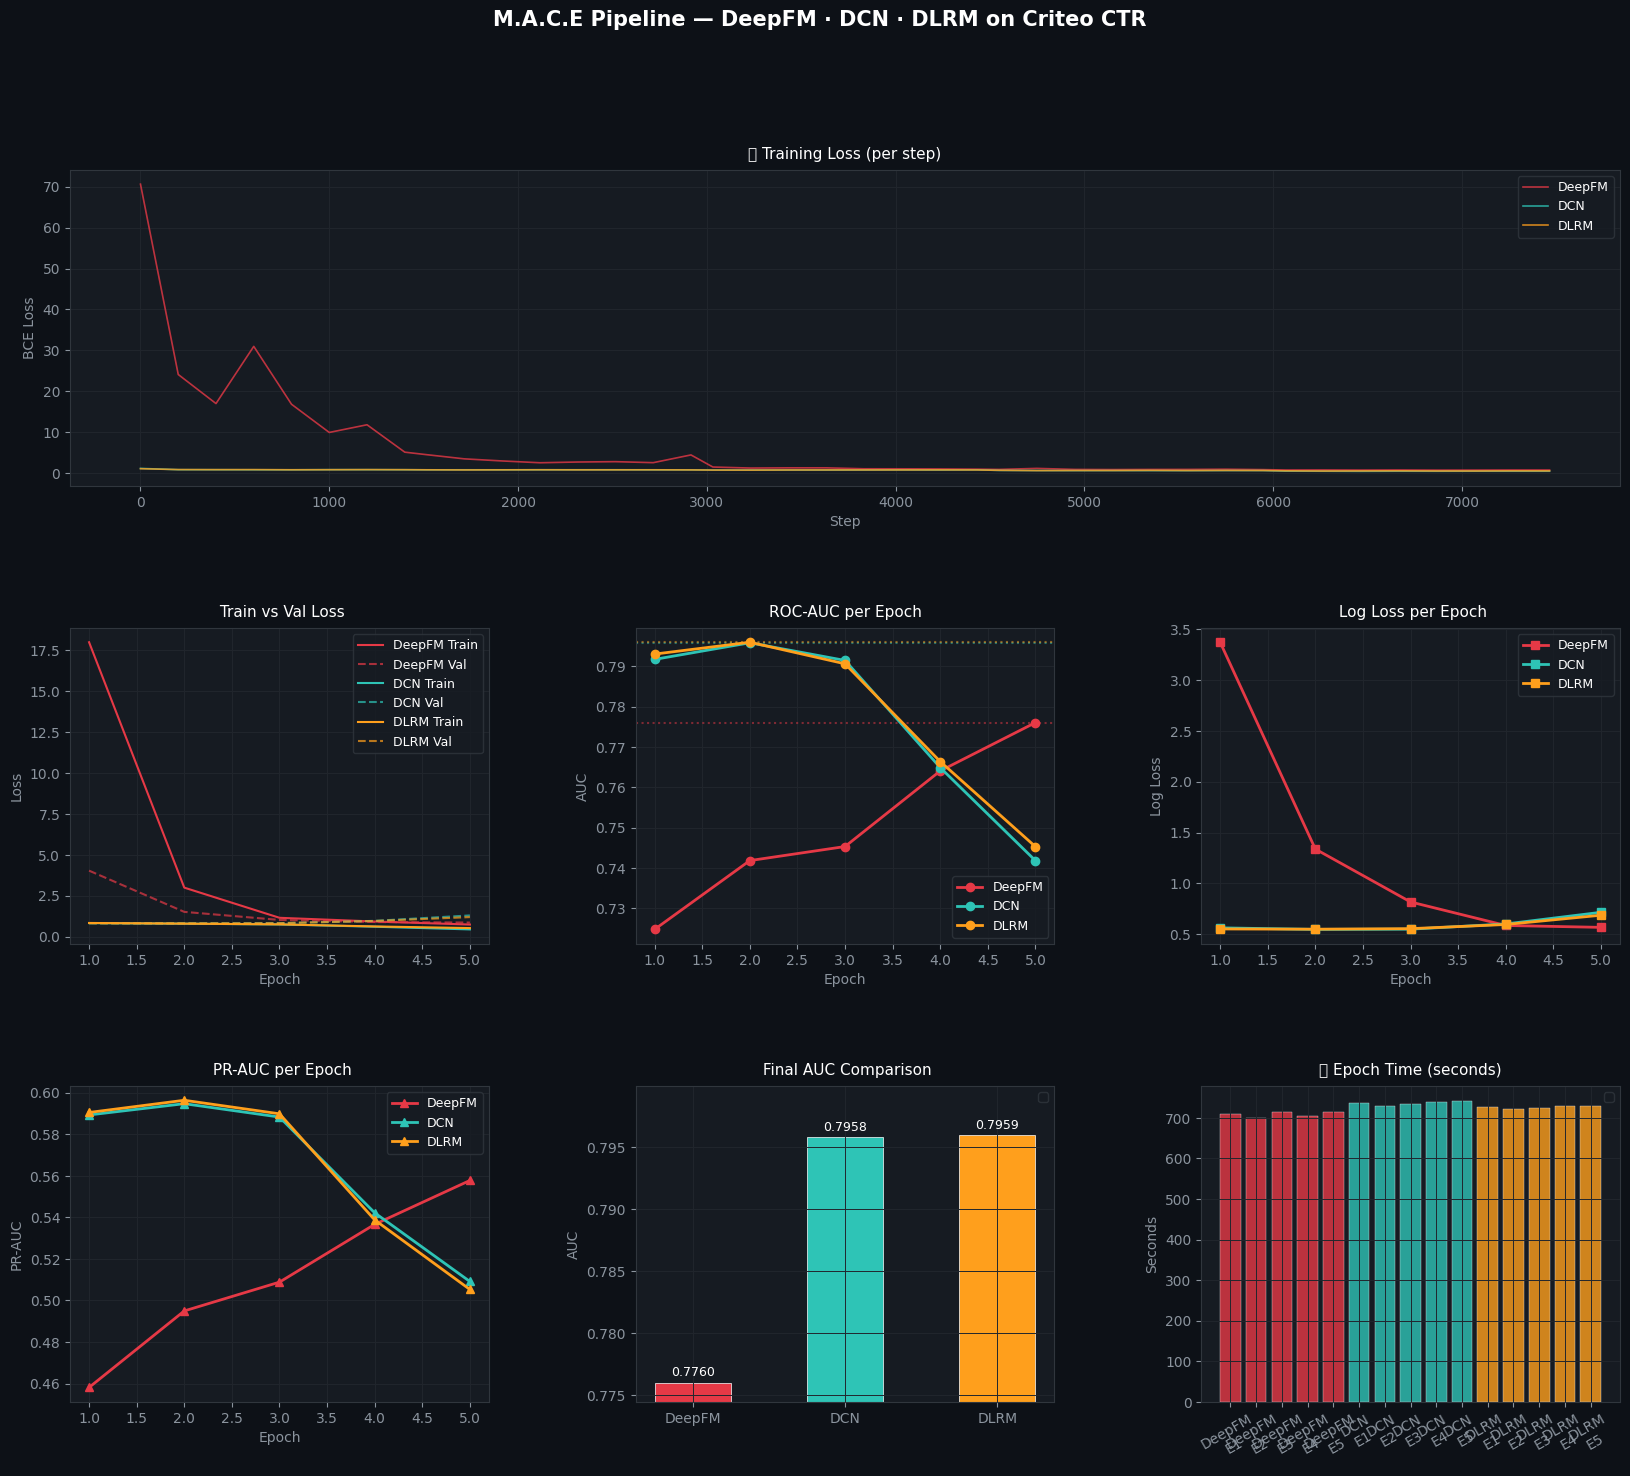

 Dashboard saved: mace_training_dashboard.png


In [18]:
# ──────────────────────────────────────────────────────────────────────────────
# Loss Curves + Metrics Dashboard
# ──────────────────────────────────────────────────────────────────────────────
colors = {'DeepFM': '#E63946', 'DCN': '#2EC4B6', 'DLRM': '#FF9F1C'}

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.patch.set_facecolor('#0D1117')

def ax_style(ax, title):
    ax.set_facecolor('#161B22')
    ax.set_title(title, color='white', fontsize=11, pad=8)
    ax.tick_params(colors='#8B949E')
    ax.spines[:].set_color('#30363D')
    ax.xaxis.label.set_color('#8B949E')
    ax.yaxis.label.set_color('#8B949E')
    ax.legend(facecolor='#161B22', edgecolor='#30363D',
              labelcolor='white', fontsize=9)
    ax.grid(True, color='#21262D', linewidth=0.7)

epochs_x = range(1, CFG['epochs'] + 1)

# Row 0: Step-level train loss
ax0 = fig.add_subplot(gs[0, :])
for name, lg in loggers.items():
    steps, losses = zip(*lg.train_step_losses)
    ax0.plot(steps, losses, color=colors[name], alpha=0.8, linewidth=1.2, label=name)
ax_style(ax0, '📉 Training Loss (per step)')
ax0.set_xlabel('Step'); ax0.set_ylabel('BCE Loss')

# Row 1: Epoch train + val loss
ax1 = fig.add_subplot(gs[1, 0])
for name, lg in loggers.items():
    ax1.plot(epochs_x, lg.epoch_train_loss, color=colors[name], linestyle='-',  label=f'{name} Train')
    ax1.plot(epochs_x, lg.epoch_val_loss,   color=colors[name], linestyle='--', label=f'{name} Val', alpha=0.7)
ax_style(ax1, ' Train vs Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')

# AUC curve
ax2 = fig.add_subplot(gs[1, 1])
for name, lg in loggers.items():
    ax2.plot(epochs_x, lg.epoch_auc, color=colors[name], marker='o', linewidth=2, label=name)
    ax2.axhline(y=lg.best_auc, color=colors[name], linestyle=':', alpha=0.5)
ax_style(ax2, 'ROC-AUC per Epoch')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')

# LogLoss curve
ax3 = fig.add_subplot(gs[1, 2])
for name, lg in loggers.items():
    ax3.plot(epochs_x, lg.epoch_logloss, color=colors[name], marker='s', linewidth=2, label=name)
ax_style(ax3, ' Log Loss per Epoch')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Log Loss')

# Row 2: PR-AUC + Bar chart + Epoch time
ax4 = fig.add_subplot(gs[2, 0])
for name, lg in loggers.items():
    ax4.plot(epochs_x, lg.epoch_prauc, color=colors[name], marker='^', linewidth=2, label=name)
ax_style(ax4, ' PR-AUC per Epoch')
ax4.set_xlabel('Epoch'); ax4.set_ylabel('PR-AUC')

# Final metric bar chart
ax5 = fig.add_subplot(gs[2, 1])
model_names  = list(final_metrics.keys())
aucs_final   = [final_metrics[n]['AUC'] for n in model_names]
bar_colors   = [colors[n] for n in model_names]
bars = ax5.bar(model_names, aucs_final, color=bar_colors, width=0.5, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, aucs_final):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
             f'{val:.4f}', ha='center', va='bottom', color='white', fontsize=9)
ax5.set_ylim(min(aucs_final)*0.998, max(aucs_final)*1.005)
ax_style(ax5, ' Final AUC Comparison')
ax5.set_ylabel('AUC')

# Epoch time
ax6 = fig.add_subplot(gs[2, 2])
for name, lg in loggers.items():
    ax6.bar([f'{name}\nE{i+1}' for i in range(len(lg.epoch_times))],
            lg.epoch_times, color=colors[name], alpha=0.8, edgecolor='white', linewidth=0.3)
ax_style(ax6, '⏱️ Epoch Time (seconds)')
ax6.set_ylabel('Seconds')
ax6.tick_params(axis='x', labelrotation=30)

fig.suptitle('M.A.C.E Pipeline — DeepFM · DCN · DLRM on Criteo CTR',
             color='white', fontsize=15, fontweight='bold', y=0.98)

plt.savefig('mace_training_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(" Dashboard saved: mace_training_dashboard.png")

In [19]:
# ──────────────────────────────────────────────────────────────────────────────
# Bảng tổng hợp cuối cùng
# ──────────────────────────────────────────────────────────────────────────────
rows = []
for name in final_metrics:
    m  = final_metrics[name]
    lg = loggers[name]
    rows.append({
        'Model'        : name,
        'AUC'          : f"{m['AUC']:.5f}",
        'LogLoss'      : f"{m['LogLoss']:.5f}",
        'PR-AUC'       : f"{m['PR-AUC']:.5f}",
        'Best AUC'     : f"{lg.best_auc:.5f}",
        'Best Epoch'   : lg.best_epoch,
        'Params (M)'   : f"{m['Params']/1e6:.2f}",
        'Avg Epoch (s)': f"{sum(lg.epoch_times)/len(lg.epoch_times):.0f}",
    })

df_results = pd.DataFrame(rows)
print("\n" + "="*80)
print("  📋 FINAL SUMMARY TABLE")
print("="*80)
print(df_results.to_string(index=False))
df_results.to_csv('mace_model_comparison.csv', index=False)
print("\n Results saved: mace_model_comparison.csv")


  📋 FINAL SUMMARY TABLE
 Model     AUC LogLoss  PR-AUC Best AUC  Best Epoch Params (M) Avg Epoch (s)
DeepFM 0.77603 0.56771 0.55776  0.77603           5     466.62           708
   DCN 0.79579 0.54768 0.59472  0.79579           2     475.61           736
  DLRM 0.79593 0.54976 0.59637  0.79593           2     466.00           726

 Results saved: mace_model_comparison.csv


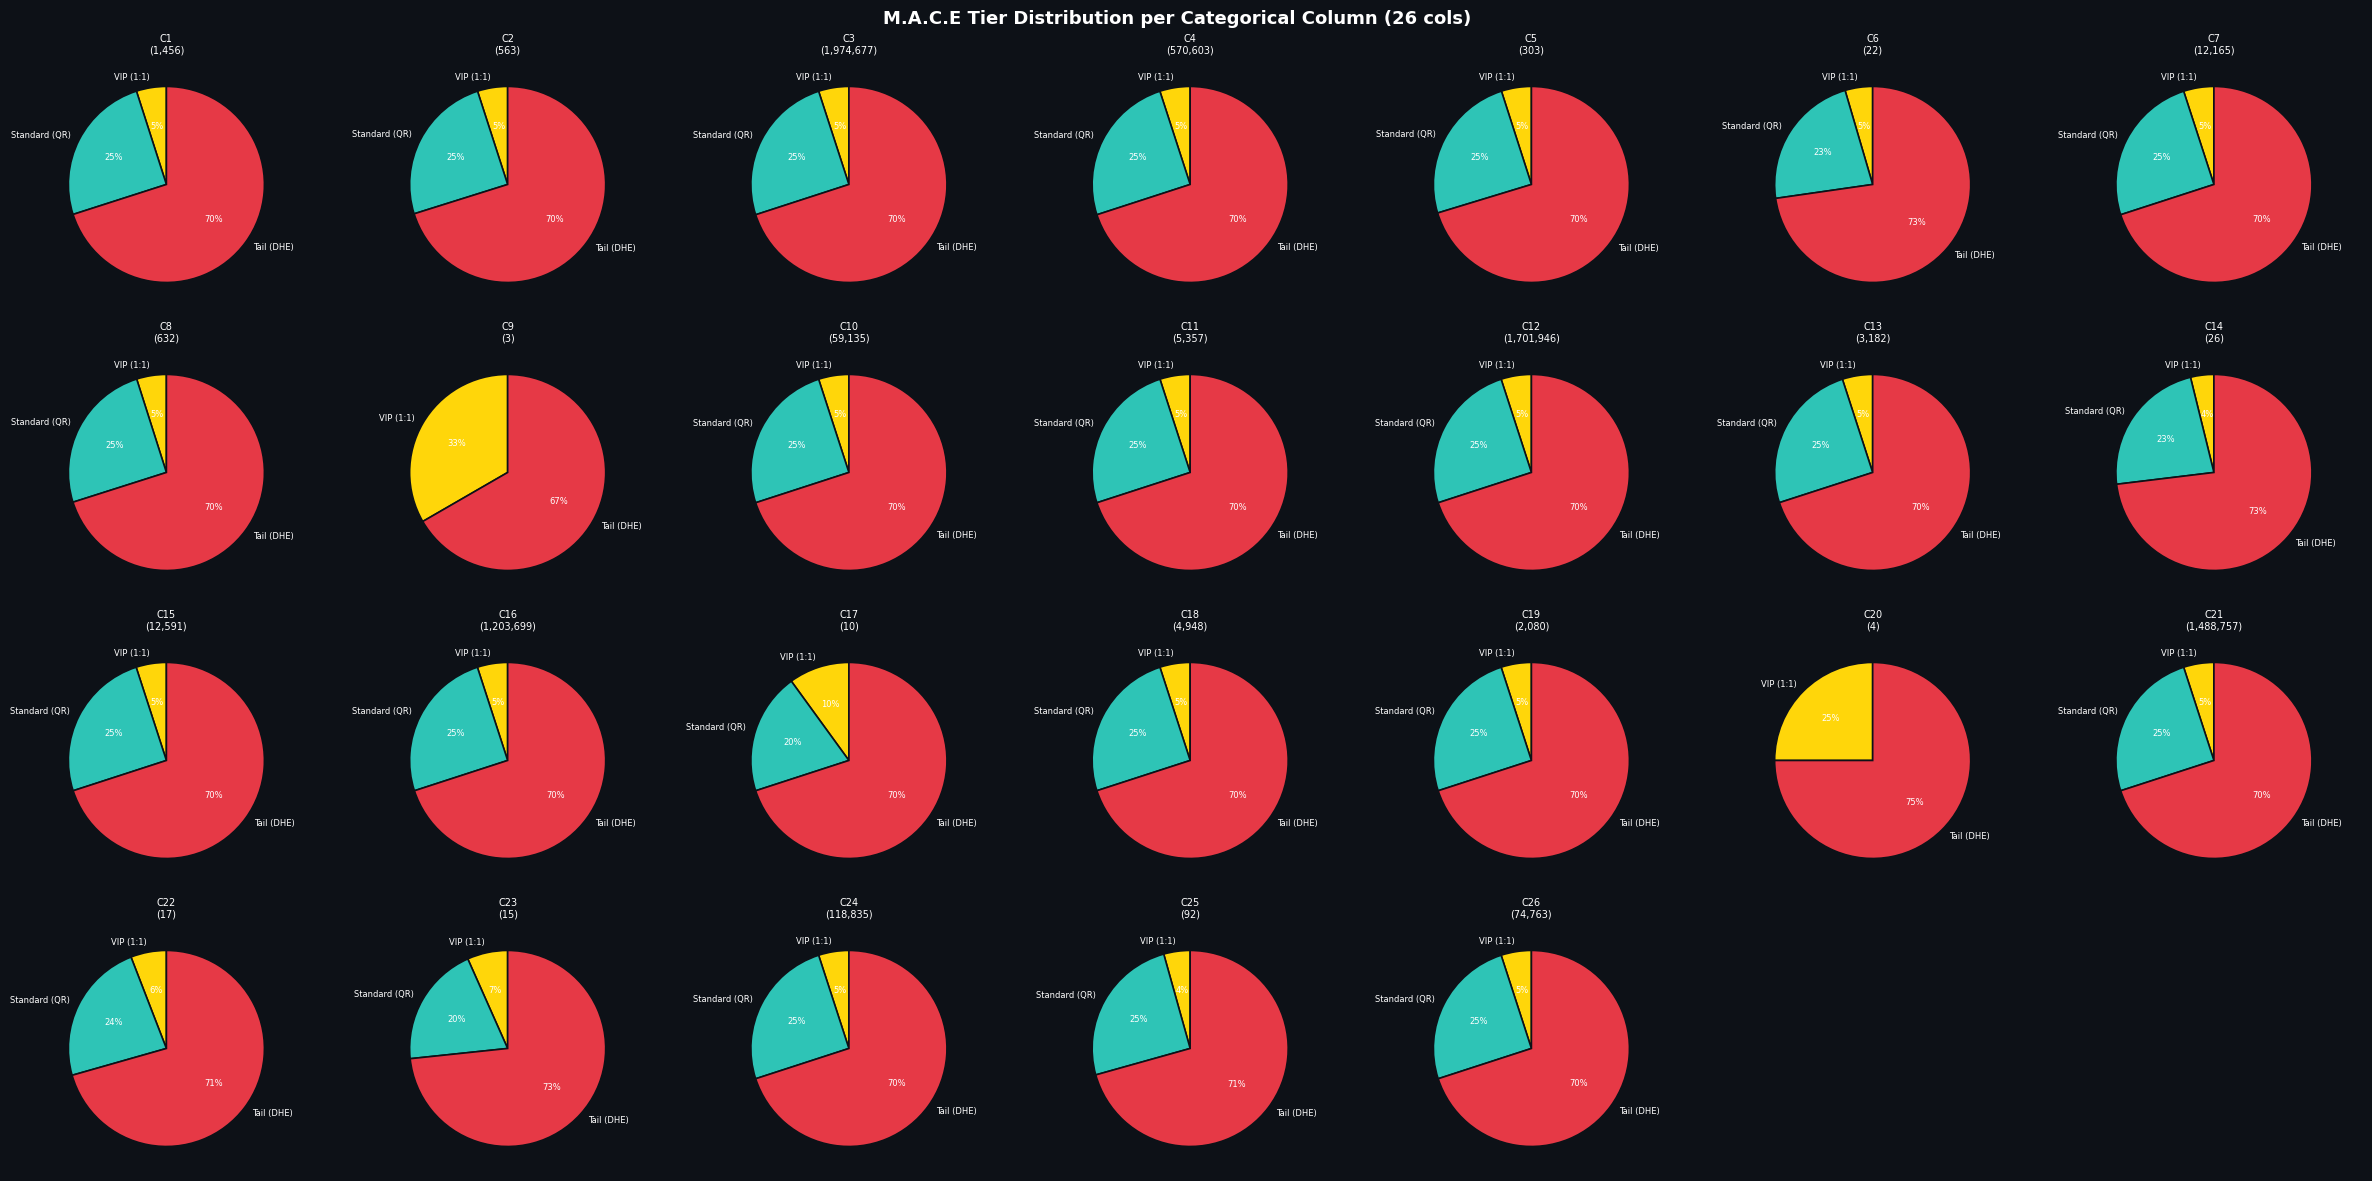

Tier distribution saved: mace_tier_distribution.png


In [20]:
# ──────────────────────────────────────────────────────────────────────────────
# Tier Distribution Analysis — phân tích M.A.C.E routing (26 categorical cols)
# ──────────────────────────────────────────────────────────────────────────────
# FIX: 26 cols cần 4x7 grid (28 slots), dùng fig/axes thay vì 2x4
fig2, axes = plt.subplots(4, 7, figsize=(24, 12))
fig2.patch.set_facecolor('#0D1117')
fig2.suptitle('M.A.C.E Tier Distribution per Categorical Column (26 cols)',
              color='white', fontsize=13, fontweight='bold')

tier_colors = ['#FFD60A', '#2EC4B6', '#E63946']  # VIP, Standard, Tail
tier_labels = ['VIP (1:1)', 'Standard (QR)', 'Tail (DHE)']

for i, ax in enumerate(axes.flatten()):
    if i >= len(SPARSE_COLS):
        ax.axis('off')
        continue
    col   = SPARSE_COLS[i]
    tr    = tier_router.tier_map[col]
    u, c  = np.unique(tr, return_counts=True)
    cnts  = {0: 0, 1: 0, 2: 0}
    for tier, cnt in zip(u, c):
        cnts[tier] = cnt

    ax.set_facecolor('#161B22')
    # Chỉ vẽ wedge có giá trị > 0
    vals   = [cnts[t] for t in [0, 1, 2]]
    clrs   = [tier_colors[t] for t in [0, 1, 2] if cnts[t] > 0]
    lbls   = [tier_labels[t] for t in [0, 1, 2] if cnts[t] > 0]
    vals_f = [v for v in vals if v > 0]

    wedges, texts, autotexts = ax.pie(
        vals_f, labels=lbls, colors=clrs,
        autopct='%1.0f%%', startangle=90,
        textprops={'color': 'white', 'fontsize': 6},
        wedgeprops={'edgecolor': '#0D1117', 'linewidth': 1.2}
    )
    for at in autotexts:
        at.set_fontsize(6)
    ax.set_title(f'{col}\n({vocab_sizes[col]:,})',
                 color='white', fontsize=7)

plt.tight_layout()
plt.savefig('mace_tier_distribution.png', dpi=120, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
plt.show()
print("Tier distribution saved: mace_tier_distribution.png")


In [21]:
# ──────────────────────────────────────────────────────────────────────────────
# Save model checkpoints
# ──────────────────────────────────────────────────────────────────────────────
for name, model in results.items():
    path = f'mace_{name.lower()}_best.pt'
    torch.save({
        'model_state_dict': model.state_dict(),
        'metrics': final_metrics[name],
        'cfg': CFG,
    }, path)
    print(f" Saved: {path}")

# Save full training log
log_export = {}
for name, lg in loggers.items():
    log_export[name] = {
        'epoch_train_loss': lg.epoch_train_loss,
        'epoch_val_loss'  : lg.epoch_val_loss,
        'epoch_auc'       : lg.epoch_auc,
        'epoch_logloss'   : lg.epoch_logloss,
        'epoch_prauc'     : lg.epoch_prauc,
        'epoch_times'     : lg.epoch_times,
        'best_auc'        : lg.best_auc,
        'best_epoch'      : lg.best_epoch,
        'step_log_sample' : lg.train_step_losses[:20],
    }

with open('mace_training_log.json', 'w') as f:
    json.dump(log_export, f, indent=2)
print(" Training log saved: mace_training_log.json")

print("\n" + "="*60)
print("   DONE — M.A.C.E Pipeline Training Complete!")
print("="*60)

 Saved: mace_deepfm_best.pt
 Saved: mace_dcn_best.pt
 Saved: mace_dlrm_best.pt
 Training log saved: mace_training_log.json

   DONE — M.A.C.E Pipeline Training Complete!
